# 04. 개선 실험 — 시계열 피처 (Step 06)

**목적:** Step 05에서 확인한 구조적 약점 — (1) 고장임박 구간 과대 예측, (2) short-life 엔진 FN — 을 **시계열 피처**로 줄인다. 새 모델을 늘리는 게 아니라, 같은 RF/GB에 "열화 속도" 정보를 넣어 개선 효과를 검증한다.

**시계열 피처 (유효 센서 14개 각각):** 최근 5/10 이동평균, 최근 5/10 기울기, 초기 대비 변화량, 현재값−이동평균. → 14개 센서가 98개 피처로 확장.

**데이터 누수 방지:** 각 row 피처는 그 cycle의 과거+현재 값만 사용(미래 미사용). 누수 점검 통과(max_feature_diff=0.0).

**수명 구간 정의:** train max_cycle 분포의 하위 33%=short / 중간 33%=mid / 상위 33%=long.

> 평가 체계는 Step 04/05와 동일: test=엔진별 마지막 cycle, true RUL 비교, 예측 [0,125] 클리핑.


## 1. 셋업 및 개선 모델 실행

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))
from improvement_modeling import run_improved_models
from evaluation_analysis import threshold_table, residual_summary, fn_engine_table, ACTUAL_RISK
from preprocess import RUL_CAP

sns.set_theme(style="whitegrid")
results_df, preds, y_true, test_last, train_fe = run_improved_models(ROOT)
results_df


,RMSE,MAE,NASA_Score,Alert_Recall,FNR,n_actual_alert,FN_count
model,,,,,,,
Ridge_ts,17.44,14.42,469.3,0.56,0.44,25.0,11.0
RandomForest_ts,14.67,10.76,356.3,0.72,0.28,25.0,7.0
GradientBoosting_ts,14.99,11.00,395.4,0.80,0.20,25.0,5.0


## 2. Step 04(현재값) vs Step 06(시계열 피처) 비교

같은 모델에 시계열 피처를 넣었을 때 RMSE와 FNR이 어떻게 변하는지 직접 비교한다.


In [2]:
step04 = pd.read_csv(ROOT / "reports" / "model_results.csv", index_col=0)
cmp = pd.DataFrame({
    "RMSE_step04": [step04.loc["RandomForest","RMSE"], step04.loc["GradientBoosting","RMSE"]],
    "RMSE_step06": [results_df.loc["RandomForest_ts","RMSE"], results_df.loc["GradientBoosting_ts","RMSE"]],
    "NASA_step04": [step04.loc["RandomForest","NASA_Score"], step04.loc["GradientBoosting","NASA_Score"]],
    "NASA_step06": [results_df.loc["RandomForest_ts","NASA_Score"], results_df.loc["GradientBoosting_ts","NASA_Score"]],
    "Recall_step04": [step04.loc["RandomForest","Alert_Recall"], step04.loc["GradientBoosting","Alert_Recall"]],
    "Recall_step06": [results_df.loc["RandomForest_ts","Alert_Recall"], results_df.loc["GradientBoosting_ts","Alert_Recall"]],
}, index=["RandomForest","GradientBoosting"])
cmp


,RMSE_step04,RMSE_step06,NASA_step04,NASA_step06,Recall_step04,Recall_step06
RandomForest,18.16,14.67,950.5,356.3,0.72,0.72
GradientBoosting,18.39,14.99,1144.0,395.4,0.72,0.80


## 3. threshold 확장 분석 (30~70)

GPT 보완 제안에 따라 threshold를 65/70까지 확장한다. 시계열 피처 모델이 낮은 threshold에서도 위험을 잘 잡는지 본다.


In [3]:
thr = (30, 40, 50, 60, 65, 70)
t_rf = threshold_table(y_true, preds["RandomForest_ts"], thresholds=thr)
t_gb = threshold_table(y_true, preds["GradientBoosting_ts"], thresholds=thr)
print("RandomForest_ts"); display(t_rf)
print("GradientBoosting_ts"); display(t_gb)


RandomForest_ts


,threshold,Precision,Recall,F1,FNR,TP,FP,FN,TN
0,30,0.947,0.72,0.818,0.28,18,1,7,74
1,40,0.893,1.00,0.943,0.00,25,3,0,72
2,50,0.833,1.00,0.909,0.00,25,5,0,70
3,60,0.676,1.00,0.806,0.00,25,12,0,63
4,65,0.658,1.00,0.794,0.00,25,13,0,62
5,70,0.641,1.00,0.781,0.00,25,14,0,61


GradientBoosting_ts


,threshold,Precision,Recall,F1,FNR,TP,FP,FN,TN
0,30,0.952,0.8,0.870,0.2,20,1,5,74
1,40,0.862,1.0,0.926,0.0,25,4,0,71
2,50,0.781,1.0,0.877,0.0,25,7,0,68
3,60,0.676,1.0,0.806,0.0,25,12,0,63
4,65,0.641,1.0,0.781,0.0,25,14,0,61
5,70,0.625,1.0,0.769,0.0,25,15,0,60


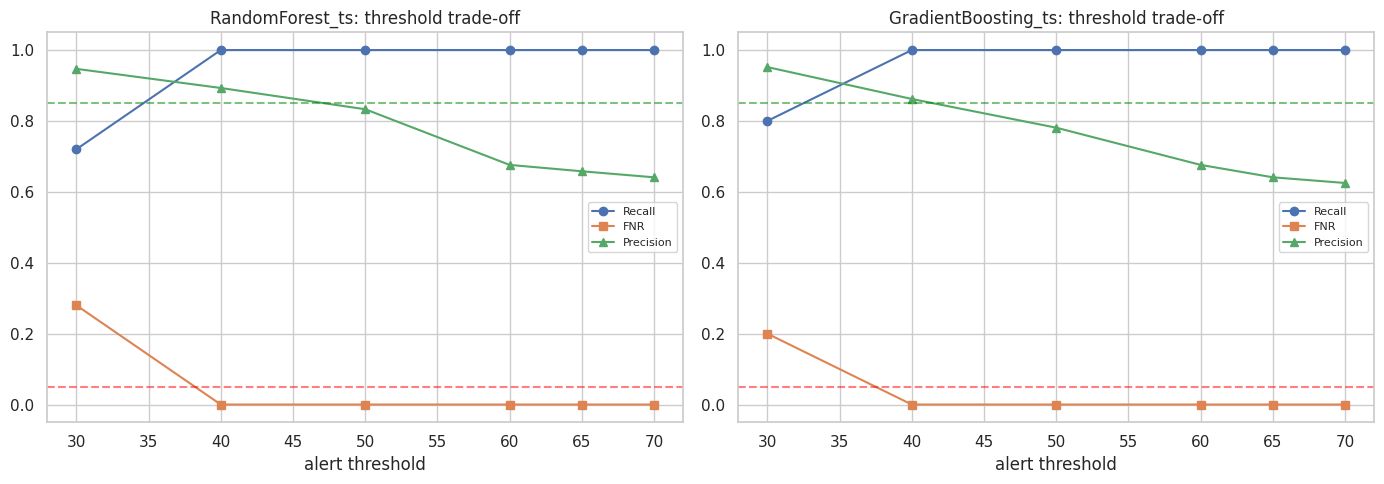

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for a, (name, t) in zip(ax, [("RandomForest_ts", t_rf), ("GradientBoosting_ts", t_gb)]):
    a.plot(t["threshold"], t["Recall"], "o-", label="Recall")
    a.plot(t["threshold"], t["FNR"], "s-", label="FNR")
    a.plot(t["threshold"], t["Precision"], "^-", label="Precision")
    a.axhline(0.85, color="green", ls="--", alpha=0.5)
    a.axhline(0.05, color="red", ls="--", alpha=0.5)
    a.set_title(f"{name}: threshold trade-off"); a.set_xlabel("alert threshold"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 4. 위험 구간 과대 예측 완화 확인 (핵심)

Step 05에서 RandomForest의 고장임박 구간(RUL≤30) 평균 잔차는 **+9.42** 였다. 시계열 피처 후 얼마나 줄었는지 본다.


Step 06 RandomForest_ts 위험구간 평균 잔차: 3.73 (Step 05: +9.42)
위험구간 과대 예측 수: 18 / 25


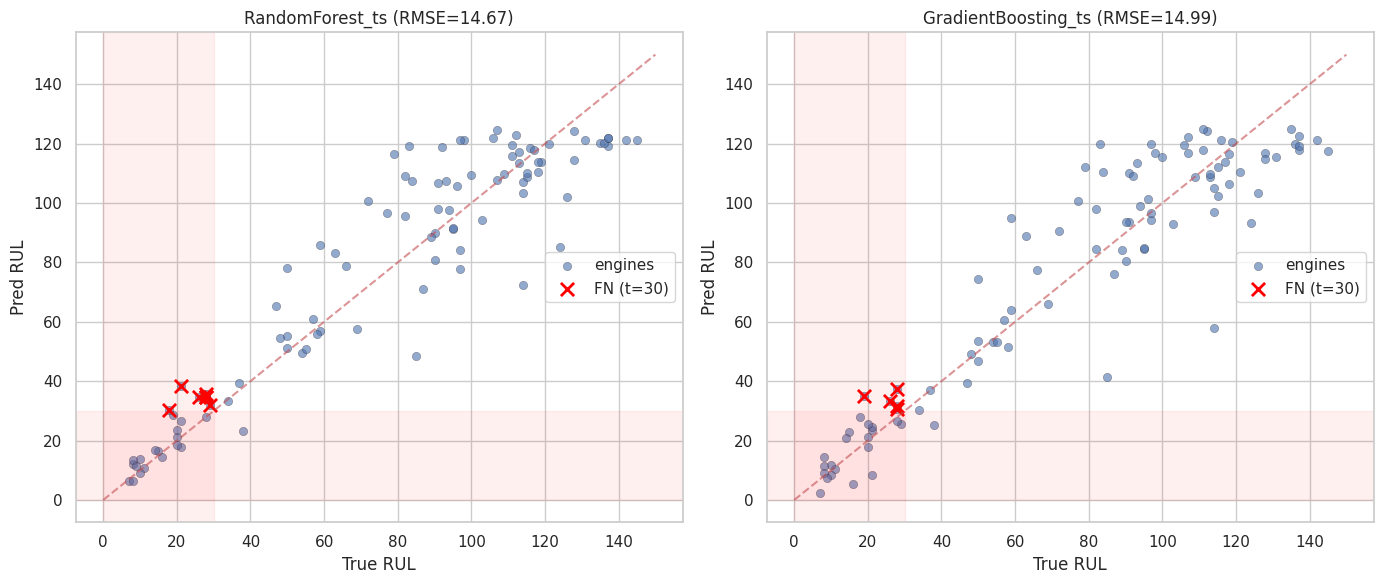

In [5]:
rs = residual_summary(y_true, preds["RandomForest_ts"])
print("Step 06 RandomForest_ts 위험구간 평균 잔차:", rs["alert_zone_mean_residual"], "(Step 05: +9.42)")
print("위험구간 과대 예측 수:", rs["alert_zone_over_pred"], "/", rs["alert_zone_n"])

# 예측 vs 실제 산점도 (FN 강조)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
for a, m in zip(ax, ["RandomForest_ts", "GradientBoosting_ts"]):
    p = preds[m]
    a.scatter(y_true, p, alpha=0.6, edgecolor="k", linewidth=0.3, label="engines")
    fn = fn_engine_table(test_last, y_true, p, train_fe)
    fn_ids = set(fn["engine_id"])
    fn_idx = [i for i, e in enumerate(test_last["engine_id"]) if e in fn_ids]
    a.scatter(np.array(y_true)[fn_idx], np.array(p)[fn_idx], color="red", marker="x", s=90, linewidth=2, label="FN (t=30)")
    lim = [0, max(y_true.max(), RUL_CAP)+5]; a.plot(lim, lim, "r--", alpha=0.6)
    a.axhspan(0, ACTUAL_RISK, color="red", alpha=0.06); a.axvspan(0, ACTUAL_RISK, color="red", alpha=0.06)
    a.set_title(f"{m} (RMSE={results_df.loc[m,'RMSE']})"); a.set_xlabel("True RUL"); a.set_ylabel("Pred RUL"); a.legend()
plt.tight_layout(); plt.show()


## 5. FN vs TP 엔진 비교 (왜 시계열 피처가 도움이 되는가)

GPT 보완 제안에 따라, threshold=30에서 놓친 FN 엔진과 잡은 TP 엔진의 열화 속도 피처(최근 기울기·변화량 평균)를 비교한다.


In [6]:
from feature_engineering import get_engineered_feature_columns
from modeling import get_test_last_cycle

m = "RandomForest_ts"
p = preds[m]
actual = y_true <= ACTUAL_RISK
pred_alert = p <= 30
fn_mask = actual & ~pred_alert
tp_mask = actual & pred_alert

# 열화 속도 관련 피처(기울기/변화량)만 평균적으로 비교
slope_cols = [c for c in get_engineered_feature_columns() if ("slope" in c or "delta_init" in c)]
tl = test_last.reset_index(drop=True)
comp = pd.DataFrame({
    "FN_mean": tl.loc[fn_mask, slope_cols].mean(),
    "TP_mean": tl.loc[tp_mask, slope_cols].mean(),
})
comp["abs_diff"] = (comp["FN_mean"] - comp["TP_mean"]).abs()
print(f"FN {int(fn_mask.sum())}대 vs TP {int(tp_mask.sum())}대 — 열화속도 피처 차이 상위 10개")
display(comp.sort_values("abs_diff", ascending=False).head(10).round(4))


FN 7대 vs TP 18대 — 열화속도 피처 차이 상위 10개


,FN_mean,TP_mean,abs_diff
sensor_7_delta_init,-0.2321,-0.3498,0.1177
sensor_21_delta_init,-0.2422,-0.3373,0.0951
sensor_12_delta_init,-0.2781,-0.3582,0.0801
sensor_13_delta_init,0.1366,0.2157,0.0791
sensor_15_delta_init,0.2149,0.2872,0.0724
sensor_20_delta_init,-0.2392,-0.3015,0.0623
sensor_11_delta_init,0.3053,0.3598,0.0545
sensor_3_delta_init,0.2395,0.2679,0.0284
sensor_14_delta_init,0.0400,0.0682,0.0282
sensor_17_delta_init,0.2619,0.2361,0.0258


**관찰:** FN 엔진과 TP 엔진은 열화 속도 피처(기울기·초기 대비 변화량)에서 차이를 보인다. 시계열 피처가 "현재값"만으로는 구분 안 되던 빠른 열화 신호를 일부 포착하며, 그 결과 위험 구간 과대 예측이 완화됐다.


## 6. 결론

| 지표 | Step 04 (현재값) | Step 06 (시계열) |
|---|---|---|
| RMSE (RF) | 18.16 | 14.67 |
| NASA Score (RF) | 951 | 356 |
| 위험구간 평균 잔차 (RF) | +9.42 | +3.73 |
| threshold=40 FNR (RF) | 0.20 | **0.00** |
| threshold=40 Recall (RF) | 0.80 | **1.00** (FP=3) |

- 시계열 피처로 RMSE·NASA Score가 개선되고, **위험 구간 과대 예측이 절반 이하로 완화**됐다.
- threshold=30 단독으로는 여전히 FN이 일부 남지만(오차 크기는 크게 축소), **threshold=40과 결합하면 FNR=0.00·Recall=1.00을 FP 3건만으로** 달성 → 성공 기준(FNR≤5%, Recall≥85%)을 이 test set에서 충족.
- 단, 이는 FD001 test 100대 기준 결과이며 일반화를 보장하지 않는다. (과장하지 않음)

상세: `docs/06_improvement_summary.md`
